# Assignment

This assignment, we focus on **content-based recommenders**.

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

The data we use in this assignment is a movie meta-data that accompanies the user-movie rating data we used in the lecture. Let's take a look:

In [2]:
df_movies = pd.read_csv('./movies.csv')
df_ratings = pd.read_csv('./ratings.csv')
df_movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


Question 1. Do some exploratory analysis of the data.  Please do at least 3 different analysis.  1 analysis/data exploration should be a visualization of some sort (bar, histogram, boxplot, etc.).

In [3]:
#Data Exploration 1
df_movies.value_counts("genres")

genres
Drama                                    1053
Comedy                                    946
Comedy|Drama                              435
Comedy|Romance                            363
Drama|Romance                             349
                                         ... 
Action|Horror|Mystery|Sci-Fi                1
Action|Horror|Mystery|Thriller              1
Children|Comedy|Drama|Mystery               1
Children|Comedy|Drama|Musical|Romance       1
Adventure|Drama|Horror|Thriller             1
Length: 951, dtype: int64

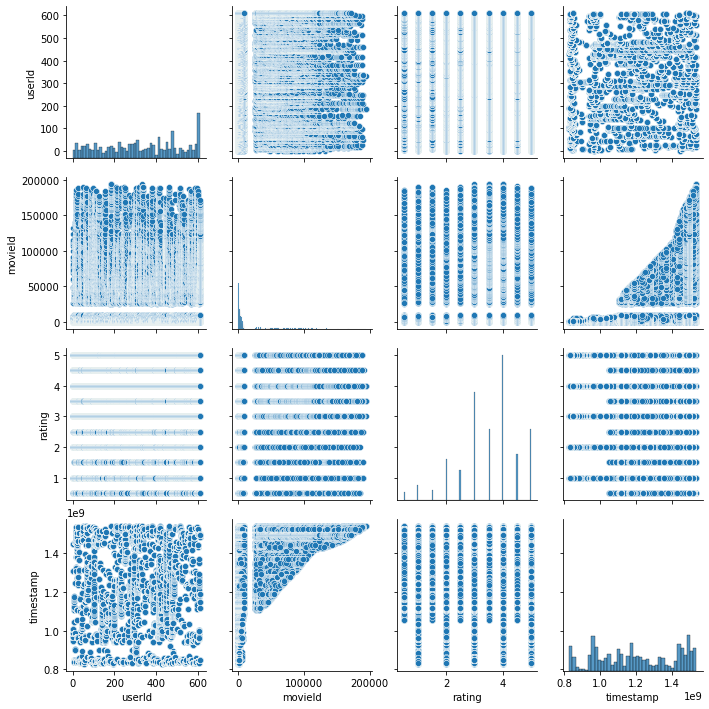

In [4]:
#Data Exploration 2
sns.pairplot(df_ratings)

<AxesSubplot:ylabel='Count'>

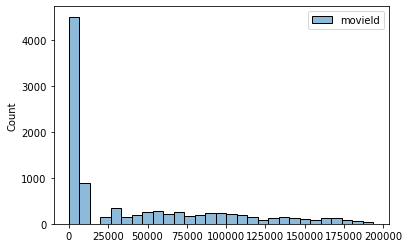

In [5]:
#Data Exploration 3
sns.histplot(df_movies)#, hue="genres")

Question 1.1: Since the `genres` column is not in the right format for us to do comparisons, create a dummy column for each genre. You can use the `str.get_dummies` method to do this.

In [6]:
df_movies.value_counts("genres").index

Index(['Drama', 'Comedy', 'Comedy|Drama', 'Comedy|Romance', 'Drama|Romance',
       'Documentary', 'Comedy|Drama|Romance', 'Drama|Thriller', 'Horror',
       'Horror|Thriller',
       ...
       'Action|Fantasy|Sci-Fi|Thriller|War', 'Action|Fantasy|Thriller|IMAX',
       'Action|Fantasy|War|IMAX', 'Action|Fantasy|Western',
       'Children|Comedy|Fantasy|Sci-Fi', 'Action|Horror|Mystery|Sci-Fi',
       'Action|Horror|Mystery|Thriller', 'Children|Comedy|Drama|Mystery',
       'Children|Comedy|Drama|Musical|Romance',
       'Adventure|Drama|Horror|Thriller'],
      dtype='object', name='genres', length=951)

In [7]:
testtext = df_movies["genres"][0]
testtext

'Adventure|Animation|Children|Comedy|Fantasy'

In [8]:
testtext.split("|")

['Adventure', 'Animation', 'Children', 'Comedy', 'Fantasy']

In [9]:
unsortedgenrelistwdups = [genres.split("|") for genres in df_movies.value_counts("genres").index]
unsortedgenrelistwdups = np.concatenate(unsortedgenrelistwdups)
genrelist              = np.unique(unsortedgenrelistwdups).tolist()

In [10]:
df_columns = df_movies.columns.tolist()

In [11]:
np.isin(genrelist,testtext.split("|"))

array([False, False,  True,  True,  True,  True, False, False, False,
        True, False, False, False, False, False, False, False, False,
       False, False])

In [12]:
df_movies.iloc[[0]]

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy


In [13]:
df_movies.head(10)

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
6,7,Sabrina (1995),Comedy|Romance
7,8,Tom and Huck (1995),Adventure|Children
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller


In [14]:
for i in range(len(df_movies)):
    for genre in genrelist:
        df_movies.at[i,genre] = np.isin(genre,df_movies["genres"][i].split("|"))
df_movies

,movieId,title,genres,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,False,False,True,True,True,True,False,...,False,False,False,False,False,False,False,False,False,False
1,2,Jumanji (1995),Adventure|Children|Fantasy,False,False,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,Grumpier Old Men (1995),Comedy|Romance,False,False,False,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,False,False,False,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False
4,5,Father of the Bride Part II (1995),Comedy,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9737,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy,False,True,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
9738,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy,False,False,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
9739,193585,Flint (2017),Drama,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9740,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation,False,True,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [15]:
df_movies = df_movies.drop(columns=['movieId','title','genres'])
df_movies.head()

,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,False,False,True,True,True,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False
1,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False
3,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False
4,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False


Questioin 1.2: Validate Question 1.1 updates by displaying the genres list for the movie `Toy Story (1995)` as the reference movie. Hint: Drop the movieId and title column and transpose the data to make it easier to read.

In [16]:
movie_chosen = df_movies.iloc[[0]].transpose()
movie_chosen

,0
(no genres listed),False
Action,False
Adventure,True
Animation,True
Children,True
Comedy,True
Crime,False
Documentary,False
Drama,False
Fantasy,True


Question 1.3: Create a new `DataFrame` that will store the similarity scores. Hint: Compy df_movies for columns movieId and title.

In [21]:
df_sim = pd.DataFrame()
df_sim.head()

""


Question 2.1: Find all the movies similar to the above movie. The easiest way to do this is by using the `pd.DataFrame.corrwith` method. You can pass `movie_chosen` to this method and specify the correct value for `axis`. The default similarity metric used is Pearson's correlation, so add a new column to the `df_sim` data called `sim_pearson` to store the similarity scores. Show the top 5 rows of the resulting data.

In [22]:
df_movies.transpose()

,0,1,2,3,4,5,6,7,8,9,...,9732,9733,9734,9735,9736,9737,9738,9739,9740,9741
(no genres listed),False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
Action,False,False,False,False,False,True,False,False,True,True,...,True,False,False,False,False,True,False,False,True,False
Adventure,True,True,False,False,False,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
Animation,True,False,False,False,False,False,False,False,False,False,...,True,True,False,True,False,True,True,False,True,False
Children,True,True,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
Comedy,True,False,True,True,True,False,True,False,False,False,...,True,False,True,False,False,True,True,False,False,True
Crime,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
Documentary,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
Drama,False,False,False,True,False,False,False,False,False,False,...,False,True,True,False,False,False,False,True,False,False
Fantasy,True,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,True,False,False,False


In [23]:
movie_test = df_movies.iloc[[1]].transpose().astype(int)
movie_test

,1
(no genres listed),0
Action,0
Adventure,1
Animation,0
Children,1
Comedy,0
Crime,0
Documentary,0
Drama,0
Fantasy,1


In [24]:
movie_chosen.corrwith(df_movies.transpose(),axis=0, method='pearson', numeric_only=False)

0       1.0
1       NaN
2       NaN
3       NaN
4       NaN
       ... 
9737    NaN
9738    NaN
9739    NaN
9740    NaN
9741    NaN
Length: 9742, dtype: object

In [25]:
movie_test.corrwith(df_movies.transpose().astype(float),axis=0, method='pearson', numeric_only=False)

1       1.0
0       NaN
2       NaN
3       NaN
4       NaN
       ... 
9737    NaN
9738    NaN
9739    NaN
9740    NaN
9741    NaN
Length: 9742, dtype: float64

#### IMPORTANT: I've been having incredible issues with using corrwith as instructed, I'm not sure what the issue is only that it doesn't work for booleans, integers, converting the dummy genre columns has no effect. I keep getting `NaN` unless I compare Toy Story to itself.
#### GOING FORWARD: I'm going to try to vectorize the genre column with `TfidfVectorizer` and use it to get the similarity scores.

In [26]:
df_movies = pd.read_csv('./movies.csv')
df_movies.head(5)

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [27]:
#I've decided to remove the movies without genre information and reset the index
n_none,n_genres = df_movies[df_movies['genres']=='(no genres listed)'].shape
print('The number of movies which do not have info about genres:',n_none)
df_movies = df_movies[~(df_movies['genres']=='(no genres listed)')].reset_index(drop=True)

The number of movies which do not have info about genres: 34


In [28]:
#Trying this instead of creating dummy genre columns
df_movies['genres'] = df_movies['genres'].str.replace('|',' ',regex=True) 

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [30]:
df_movies['genres']

0       Adventure Animation Children Comedy Fantasy
1                        Adventure Children Fantasy
2                                    Comedy Romance
3                              Comedy Drama Romance
4                                            Comedy
                           ...                     
9703                Action Animation Comedy Fantasy
9704                       Animation Comedy Fantasy
9705                                          Drama
9706                               Action Animation
9707                                         Comedy
Name: genres, Length: 9708, dtype: object

In [31]:
# change 'Sci-Fi' to 'SciFi' and 'Film-Noir' to 'Noir'
df_movies['genres'] = df_movies['genres'].str.replace('Sci-Fi','SciFi')
df_movies['genres'] = df_movies['genres'].str.replace('Film-Noir','Noir')
# create an object for TfidfVectorizer
tfidf_vector = TfidfVectorizer(stop_words='english')
# apply the object to the genres column
tfidf_matrix = tfidf_vector.fit_transform(df_movies['genres'])
tfidf_matrix

<9708x19 sparse matrix of type '<class 'numpy.float64'>'
	with 22050 stored elements in Compressed Sparse Row format>

In [32]:
import scipy.sparse
tfidf_df = pd.DataFrame.sparse.from_spmatrix(tfidf_matrix)

In [33]:
print(tfidf_matrix)

  (0, 8)	0.48301747178653426
  (0, 4)	0.26738777563975086
  (0, 3)	0.5048957307474672
  (0, 2)	0.5162876752057701
  (0, 1)	0.41680359510322523
  (1, 8)	0.5936766667075072
  (1, 3)	0.6205672299106341
  (1, 1)	0.5122932056626417
  (2, 14)	0.8211549883098352
  (2, 4)	0.5707052524498741
  (3, 7)	0.46621627821471856
  (3, 14)	0.7264518207332316
  (3, 4)	0.5048862585582906
  (4, 4)	1.0
  (5, 16)	0.54199651313536
  (5, 5)	0.6360178869502786
  (5, 0)	0.5492913864502283
  (6, 14)	0.8211549883098352
  (6, 4)	0.5707052524498741
  (7, 3)	0.7711748361437065
  (7, 1)	0.6366234146642168
  (8, 0)	1.0
  (9, 16)	0.5456887973497062
  (9, 0)	0.5530333660868391
  (9, 1)	0.6295854449093398
  :	:
  (9697, 15)	0.5913191062787809
  (9697, 0)	0.47943055416258734
  (9697, 4)	0.3501379182036541
  (9697, 1)	0.5457943720129674
  (9698, 15)	0.5492215161139528
  (9698, 0)	0.44529860955378636
  (9698, 4)	0.32521066247118957
  (9698, 2)	0.6279354262836311
  (9699, 7)	0.43143837610982116
  (9699, 2)	0.9021424098332371
 

In [34]:
print(tfidf_matrix.data)

[0.48301747 0.26738778 0.50489573 ... 0.5784593  0.81571125 1.        ]


In [35]:
print(tfidf_matrix.indices)

[8 4 3 ... 0 2 4]


In [36]:
print(tfidf_matrix[0,8])

0.48301747178653426


In [37]:
for i in range(19):
    print(i,tfidf_matrix[0,i])

0 0.0
1 0.41680359510322523
2 0.5162876752057701
3 0.5048957307474672
4 0.26738777563975086
5 0.0
6 0.0
7 0.0
8 0.48301747178653426
9 0.0
10 0.0
11 0.0
12 0.0
13 0.0
14 0.0
15 0.0
16 0.0
17 0.0
18 0.0


#### The above is a method of finding the proportion of genre one movie is, I imagine using this to calculate the similarity score wouldn't make sense if I apply the pearson method, but I'm going to try.

#### I can't for the life of me figure out how to easily calculate the similarity of movies by genre using the pearson coefficients with corrwith, nor with the tfidf matrix alone. I'm going to attempt to get the simlarity scores nonetheless.

In [38]:
movie_chosen = tfidf_df.iloc[[0]]
movie_chosen

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,0.0,0.416804,0.516288,0.504896,0.267388,0.0,0.0,0.0,0.483017,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [39]:
movie_chosen.transpose().sparse.to_dense().corrwith(tfidf_df.transpose().sparse.to_dense(),axis=0, method='pearson', numeric_only=False)

0       1.0
1       NaN
2       NaN
3       NaN
4       NaN
       ... 
9703    NaN
9704    NaN
9705    NaN
9706    NaN
9707    NaN
Length: 9708, dtype: float64

#### Okay I'm convinced that there's some issues with `corrwith` and after seeing that my classmates are also having issues with it I think I'm going to revisit this portion of the assignment after I get help.

Question 2.2: Pearson's correlation may not be the best similarity metric to use with the data we have, so try [Jaccard similarity](https://en.wikipedia.org/wiki/Jaccard_index) instead. To specify another similarity function, we can use the `method` argument of `corrwith`. Unforetunately, Jaccard similarity is not one of the default metrics offered, but `method` also accepts functions (referred to as a "callable" in the doc).

- Use `corrwith` to find the similarity between `Toy Story (1995)` and other movies, using Jaccard similarity. Add the similarity scores to `df_sim` as a new column calld `sim_jaccard` and show the top 5 rows.

Question 2.3: Use `corrwith` to find the similarity between `Toy Story (1995)` and other movies, but this time use cosine similarity. Add the similarity scores to `df_sim` as a new column calld `sim_cosine` and show the top 5 rows. 

***

---

We built a simple example of a recommender system above. Now let's make this more interesting by adding additional information to the above table that can help us filter the recommendations. Specifically, we want to be able to filter by the movie's popularity (number of users who rated it) and its average rating (average over users). This information is not part of the movie meta-data, so we have to turn to the data with the ratings. This makes it a basic example of a hybrid approach.

The code below will load the data and reshape it from long to wide using `pivot_table`:

In [37]:
df_ratings = pd.read_csv('./ratings.csv')

In [40]:
df_ratings

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
...,...,...,...,...
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352


In [41]:
movie_user_mat = df_ratings.pivot_table(index = 'movieId', columns = 'userId', values = 'rating')
movie_user_mat.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
movieId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,NaN,NaN,4.0,NaN,4.5,NaN,NaN,NaN,...,4.0,NaN,4.0,3.0,4.0,2.5,4.0,2.5,3.0,5.0
2,NaN,NaN,NaN,NaN,NaN,4.0,NaN,4.0,NaN,NaN,...,NaN,4.0,NaN,5.0,3.5,NaN,NaN,2.0,NaN,NaN
3,4.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN


Question 3.1: From the table above, extract the average rating of each movie and the number of ratings received by each movie. Add those as two new columns to `df_sim`, and call them `ratings_avg` and `ratings_cnt` respectively. Show the top 5 rows. 

In [46]:
df_ratings.groupby('movieId')['rating'].mean()#.reset_index()

movieId
1         3.920930
2         3.431818
3         3.259615
4         2.357143
5         3.071429
            ...   
193581    4.000000
193583    3.500000
193585    3.500000
193587    3.500000
193609    4.000000
Name: rating, Length: 9724, dtype: float64

In [41]:
df_ratings.value_counts(subset='movieId').sort_index()

movieId
1         215
2         110
3          52
4           7
5          49
         ... 
193581      1
193583      1
193585      1
193587      1
193609      1
Length: 9724, dtype: int64

In [52]:
df_sim['ratings_avg'] = df_ratings.groupby('movieId')['rating'].mean()
df_sim['ratings_cnt'] = df_ratings.value_counts(subset='movieId').sort_index().astype(int)
df_sim.head()

,Toy Story Similarity,ratings_avg,ratings_cnt
0,1.000000,NaN,NaN
1,0.813604,3.920930,215.0
2,0.152600,3.431818,110.0
3,0.135000,3.259615,52.0
4,0.267388,2.357143,7.0


In [90]:
df_sim.index.value_counts()

0       1
6466    1
6468    1
6469    1
6470    1
       ..
3236    1
3237    1
3238    1
3239    1
9707    1
Length: 9708, dtype: int64

Question 3.2: Now find all the movies that are similar to `Toy Story (1995)` using cosine similarity, just like we did earlier, but this time limit the results to movies in the bottom 40th percentile in terms of popularity (`ratings_cnt`) and the top 40th percentile in terms of average rating (`ratings_avg`). Show the top 5 rows.

In [48]:
from sklearn.metrics.pairwise import linear_kernel
#Cosine Similarity Matrix, contains all similarity values of all movies with every other movie
sim_matrix = linear_kernel(tfidf_matrix,tfidf_matrix)
#Cosine Similarity Vector, contains all similarity values of all movies with just Toy Story
sim_vector = pd.DataFrame(sim_matrix[0])

In [49]:
sim_vector

,0
0,1.000000
1,0.813604
2,0.152600
3,0.135000
4,0.267388
...,...
9703,0.680280
9704,0.755880
9705,0.000000
9706,0.421142


In [50]:
df_sim["Toy Story Similarity"] = sim_vector

In [57]:
ratings_cnt_p = df_sim.sort_values(by='ratings_cnt',ascending=False).ratings_cnt.quantile(0.4)
df_sim[df_sim['ratings_cnt']<ratings_cnt_p].index[:5]

Int64Index([40, 49, 53, 55, 77], dtype='int64')

In [58]:
ratings_avg_p = df_sim.sort_values(by='ratings_cnt',ascending=True).ratings_cnt.quantile(0.4)
df_sim[df_sim['ratings_avg']<ratings_avg_p].index[:5]

Int64Index([4, 8, 12, 19, 20], dtype='int64')

In [78]:
list(less_known.append(high_rating).values)

[40, 49, 53, 55, 77, 4, 8, 12, 19, 20]

In [81]:
less_known = df_sim[df_sim['ratings_cnt']<ratings_cnt_p].index[:5]
high_rating = df_sim[df_sim['ratings_avg']<ratings_avg_p].index[:5]
df_sim.iloc[list(less_known.append(high_rating).values)].sort_values("Toy Story Similarity", ascending = False)

,Toy Story Similarity,ratings_avg,ratings_cnt
12,0.833785,2.421053,19.0
53,0.813604,5.000000,2.0
49,0.571328,3.000000,1.0
40,0.553347,4.250000,2.0
77,0.286092,4.000000,1.0
4,0.267388,2.357143,7.0
20,0.115720,2.500000,15.0
19,0.094145,2.727273,88.0
55,0.000000,4.000000,1.0
8,0.000000,2.875000,8.0


In [93]:
print("Lesser known titles that are similar to Toy Story")
df_movies.iloc[list(less_known.values)]['title']

Lesser known titles that are similar to Toy Story


40                  Mortal Kombat (1995)
49                 Big Green, The (1995)
53    Indian in the Cupboard, The (1995)
55             Mr. Holland's Opus (1995)
77                   White Squall (1996)
Name: title, dtype: object

In [88]:
print("Highly reputable titles that are similar to Toy Story")
df_movies.iloc[list(high_rating.values)]['title']

Highly reputable titles that are similar to Toy Story


4     Father of the Bride Part II (1995)
8                    Sudden Death (1995)
12                          Balto (1995)
19                    Money Train (1995)
20                     Get Shorty (1995)
Name: title, dtype: object

[Bonus] Question 4: In the exercise above, we obtained similarity scores between `Toy Story (1995)` and all other movies. Perfomed all possible pairwise comparisons. 

In [ ]:
sim_mat = #To Do
print(sim_mat)

In [ ]:
from scipy.spatial.distance import pdist, squareform
sim_mat = #To Do
print(sim_mat)

Question 5: Create a new text cell in your Notebook: Complete a 50-100 word summary (or short description of your thinking in applying this week's learning to the solution) of your experience in this assignment. Include: What was your incoming experience with this model, if any? what steps you took, what obstacles you encountered. how you link this exercise to real-world, machine learning problem-solving. (What steps were missing? What else do you need to learn?) This summary allows your instructor to know how you are doing and allot points for your effort in thinking and planning, and making connections to real-world work.

#### I had incredible issues completing this assignment, especially with corrwith. I also feel I can do better overall and I plan on revisiting this code to improve on it. I think this would be great for a music streaming service, that way they can build playlists for users based on existing playlists or liked songs.